<a href="https://colab.research.google.com/github/Sunay-2103/SunayMukherjee_23FE10CSE00636/blob/main/ANN_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Accuracy

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Seed_Data.csv') # Load the seed data

# Assuming the last column is the target and the rest are features
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (210, 7)
Target Shape: (210,)


In [ ]:
# df is already loaded in the previous cell from Seed_Data.csv
# Display the first 5 rows of the new dataframe
display(df.head())

,A,P,C,LK,WK,A_Coef,LKG,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (168, 7)
Testing Shape: (42, 7)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaled Training Data Sample:")
print(X_train[:5])

Scaled Training Data Sample:
[[-1.05385596 -1.04083248 -0.88880831 -0.86174582 -1.13018592  1.03548208
  -0.22342116]
 [ 1.52927104  1.5495697   0.46355711  1.60878046  1.46287997 -0.1265987
   1.69031688]
 [-0.86392015 -0.87893234 -0.40975723 -0.96258363 -0.73186961  1.222849
  -0.76198116]
 [-0.17669786 -0.14652697  0.0862514  -0.16046471 -0.29345435 -1.48822186
  -0.23781017]
 [-1.2230715  -1.31837557 -0.4648693  -1.34301718 -1.10612655 -0.21453263
  -0.84831521]]


In [ ]:
model = Sequential()

# Hidden Layer 1
# Use X.shape[1] for input_dim to dynamically adjust to the number of features in Seed_Data.csv
model.add(Dense(16, activation='relu', input_dim=X.shape[1]))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))

# Output Layer
# Assuming binary classification for Seed_Data, same as the breast cancer dataset.
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.3209 - loss: 0.3925 - val_accuracy: 0.3824 - val_loss: 0.1567
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3209 - loss: 0.3325 - val_accuracy: 0.3824 - val_loss: 0.0825
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3209 - loss: 0.2801 - val_accuracy: 0.3824 - val_loss: 0.0114
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3209 - loss: 0.2236 - val_accuracy: 0.3824 - val_loss: -0.0522
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3209 - loss: 0.1745 - val_accuracy: 0.3824 - val_loss: -0.1137
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.3209 - loss: 0.1277 - val_accuracy: 0.3824 - val_loss: -0.1714
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3284 - loss: 0.0848 - val_accuracy: 0.3824 - val_loss: -0.2291
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.3358 - loss: 0.0375 - val_accuracy: 0.3824 - val_loss: -

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3810 - loss: -0.7489
Test Accuracy: 0.380952388048172
Test Loss: -0.7489466667175293


In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5)

print(y_pred[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[[ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]]


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 2  9  0]
 [ 0 14  0]
 [ 0 17  0]]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.38095238095238093


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.18      0.31        11
           1       0.35      1.00      0.52        14
           2       0.00      0.00      0.00        17

    accuracy                           0.38        42
   macro avg       0.45      0.39      0.28        42
weighted avg       0.38      0.38      0.25        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


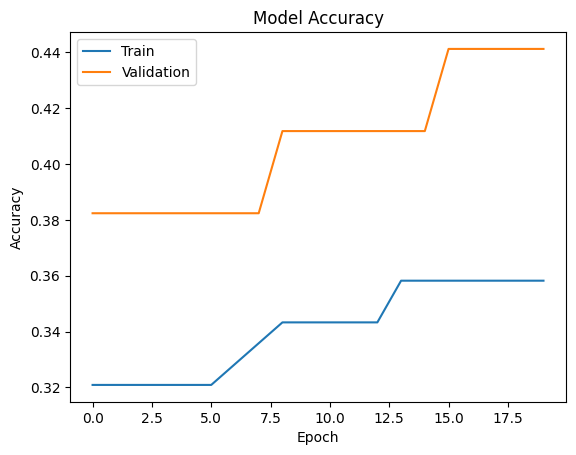

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

CNN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


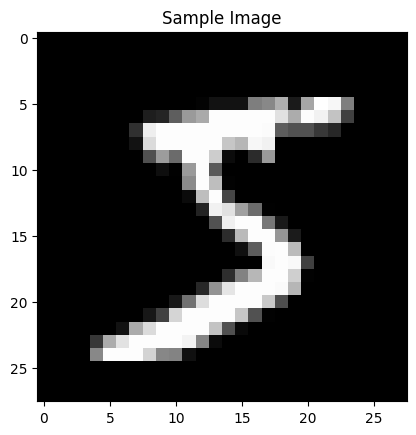

Label: 5


In [ ]:
plt.imshow(X_train[0], cmap='gray')
plt.title("Sample Image")
plt.show()

print("Label:", y_train[0])

In [ ]:
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

print("New Training Shape:", X_train.shape)

New Training Shape: (60000, 28, 28, 1)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalized Data Sample:")
print(X_train[0])

Normalized Data Sample:
[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.       

In [ ]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - accuracy: 0.9103 - loss: 0.2902 - val_accuracy: 0.9806 - val_loss: 0.0663
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9704 - loss: 0.0998 - val_accuracy: 0.9860 - val_loss: 0.0485
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.9780 - loss: 0.0730 - val_accuracy: 0.9872 - val_loss: 0.0429
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.9821 - loss: 0.0591 - val_accuracy: 0.9887 - val_loss: 0.0385
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 57ms/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.9898 - val_loss: 0.0370


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9904 - loss: 0.0317
Test Accuracy: 0.9904000163078308
Test Loss: 0.03171481564640999


In [ ]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
[7 2 1 0 4 1 4 9 5 9]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_labels)

print(cm)

[[ 971    1    1    0    0    1    5    1    0    0]
 [   0 1130    2    1    0    1    1    0    0    0]
 [   0    0 1028    0    1    0    0    3    0    0]
 [   0    0    2 1001    0    5    0    1    1    0]
 [   0    0    0    0  976    0    2    0    0    4]
 [   0    0    0    3    0  887    1    1    0    0]
 [   1    2    0    0    1    6  947    0    1    0]
 [   0    2    7    1    0    0    0 1011    1    6]
 [   3    0    2    1    0    3    2    1  959    3]
 [   1    3    0    0    3    6    0    0    2  994]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



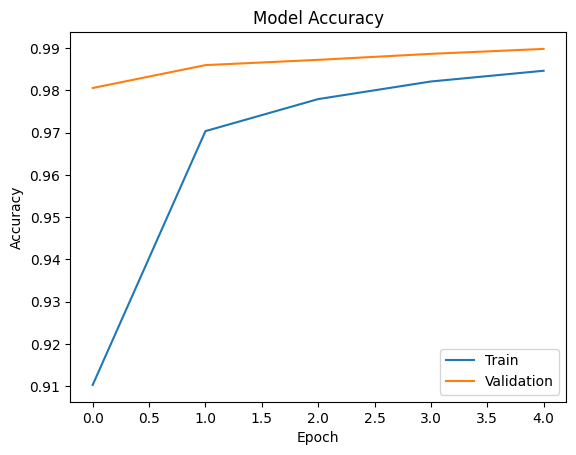

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

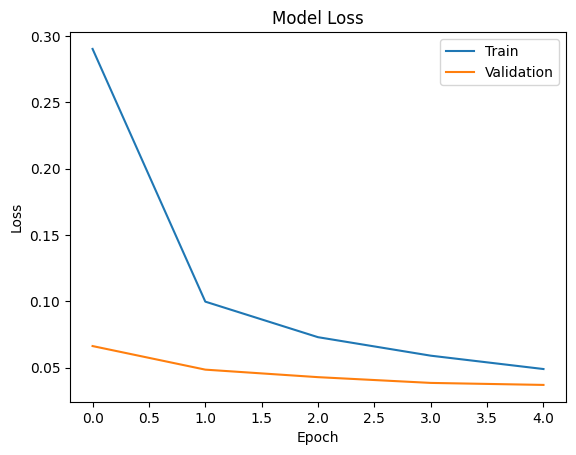

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()